# 5. Evaluation & Ablation Study

Comprehensive evaluation of the trained models:
1. Load the best Advanced Ensemble checkpoint.
2. Per-class classification report and confusion matrix.
3. Gating weight analysis (which expert handles which attack type).
4. Uncertainty analysis.
5. Ablation table comparing all explored architectures.
6. Comparison with published baselines.

In [1]:
import sys, os, gc
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_recall_fscore_support,
)
from torch.utils.data import DataLoader
import warnings
warnings.filterwarnings('ignore')

from src.dataset import (
    create_flow_based_sequences,
    create_binary_labels,
    create_anomaly_scores,
    MultiTaskDataset,
)
from src.models import AdvancedEnsembleTransformer
from src.evaluation import (
    evaluate_model,
    plot_confusion_matrix,
    plot_gate_weights,
    plot_uncertainty_distribution,
    print_ablation_table,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 5.1 Load Data & Model

In [2]:
DATA_DIR = '../data'
SEQ_LEN  = 64

X_train = pd.read_csv(f'{DATA_DIR}/preprocessed_train_X.csv')
y_train = pd.read_csv(f'{DATA_DIR}/preprocessed_train_y.csv').squeeze()
X_test  = pd.read_csv(f'{DATA_DIR}/preprocessed_test_X.csv')
y_test  = pd.read_csv(f'{DATA_DIR}/preprocessed_test_y.csv').squeeze()

X_train.columns = X_train.columns.str.strip()
X_test.columns  = X_test.columns.str.strip()
for col in ['SimillarHTTP', 'SimilarHTTP']:
    if col in X_train.columns:
        X_train.drop(columns=[col], inplace=True)
        X_test.drop(columns=[col], inplace=True)

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc  = label_encoder.transform(y_test)
num_classes  = len(label_encoder.classes_)

X_seq_test, y_seq_test, proto_test, temp_test = create_flow_based_sequences(
    X_test, y_test_enc, seq_len=SEQ_LEN
)
feature_dim = X_seq_test.shape[-1]

y_bin_test  = create_binary_labels(y_seq_test, label_encoder)
y_anom_test = create_anomaly_scores(y_seq_test, label_encoder)

test_ds = MultiTaskDataset(X_seq_test, proto_test, temp_test,
                           y_seq_test, y_bin_test, y_anom_test)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print(f'Test sequences: {X_seq_test.shape[0]} | Feature dim: {feature_dim}')

Test sequences: 760 | Feature dim: 43


In [3]:
# Load ensemble model
ensemble = AdvancedEnsembleTransformer(
    feature_dim=feature_dim, embed_dim=128, num_heads=8,
    transformer_depth=6, num_classes=num_classes, num_experts=3,
).to(device)

# Load trained weights — adjust path if needed
CHECKPOINT = '../checkpoints/best_advanced_advancedensemble_model.pth'
if os.path.exists(CHECKPOINT):
    ensemble.load_state_dict(torch.load(CHECKPOINT, map_location=device))
    print(f'Loaded checkpoint: {CHECKPOINT}')
else:
    print(f'Checkpoint not found at {CHECKPOINT} — using random weights.')
    print('Run notebook 04 first to train the model.')

Loaded checkpoint: ../checkpoints/best_advanced_advancedensemble_model.pth


## 5.2 Full Evaluation

In [4]:
metrics = evaluate_model(ensemble, test_loader, device)

print('=== Multi-Task Performance ===')
print(f'Binary F1 (weighted)      : {metrics["binary_f1"]:.4f}')
print(f'Multiclass F1 (weighted)  : {metrics["multiclass_f1"]:.4f}')
print(f'Anomaly Correlation       : {metrics["anomaly_corr"]:.4f}')
print(f'Binary Accuracy           : {metrics["binary_acc"]:.4f}')
print(f'Multiclass Accuracy       : {metrics["multiclass_acc"]:.4f}')

=== Multi-Task Performance ===
Binary F1 (weighted)      : 0.9816
Multiclass F1 (weighted)  : 0.9307
Anomaly Correlation       : 0.9751
Binary Accuracy           : 0.9816
Multiclass Accuracy       : 0.9316


## 5.3 Per-Class Report

In [5]:
class_names = label_encoder.classes_

print(classification_report(
    metrics['multiclass_targets'],
    metrics['multiclass_preds'],
    labels=np.arange(num_classes),
    target_names=class_names,
    digits=3,
    zero_division=0,
))

              precision    recall  f1-score   support

      BENIGN      0.987     0.974     0.980       232
   DrDoS_DNS      1.000     0.956     0.977        45
   DrDoS_NTP      0.904     0.979     0.940        48
  DrDoS_SNMP      0.914     0.727     0.810        44
  DrDoS_SSDP      0.956     0.977     0.966        44
        LDAP      0.976     0.953     0.965        43
       MSSQL      1.000     0.977     0.989        44
     NetBIOS      0.735     0.818     0.774        44
     Portmap      0.872     0.976     0.921        42
         Syn      0.977     1.000     0.989        43
        TFTP      1.000     1.000     1.000        43
         UDP      0.964     0.614     0.750        44
     UDP-lag      0.717     0.977     0.827        44

    accuracy                          0.932       760
   macro avg      0.923     0.918     0.914       760
weighted avg      0.939     0.932     0.931       760



## 5.4 Confusion Matrix

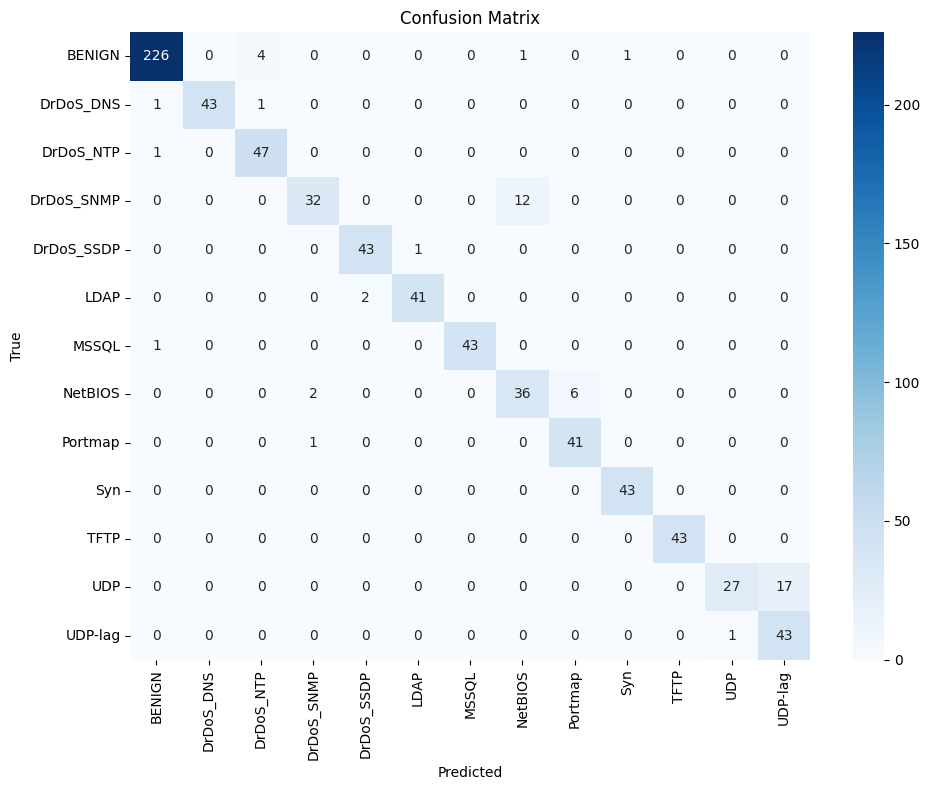

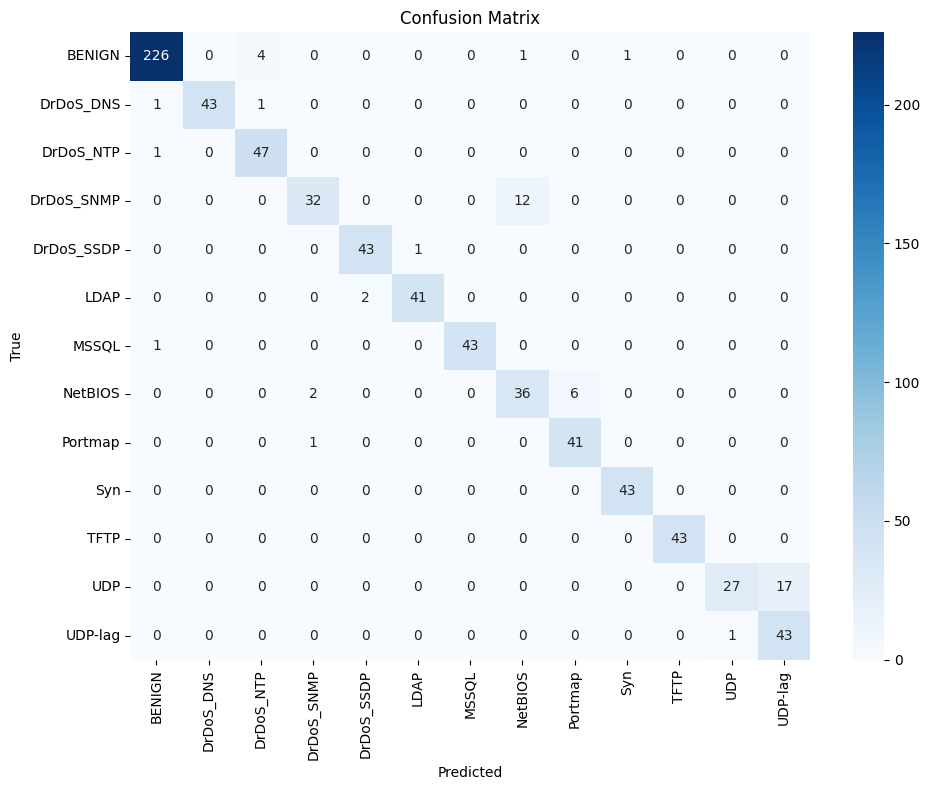

In [6]:
plot_confusion_matrix(
    metrics['multiclass_targets'],
    metrics['multiclass_preds'],
    class_names,
    save_path='../results/figures/confusion_matrix.png',
)

## 5.5 Expert Gating Analysis

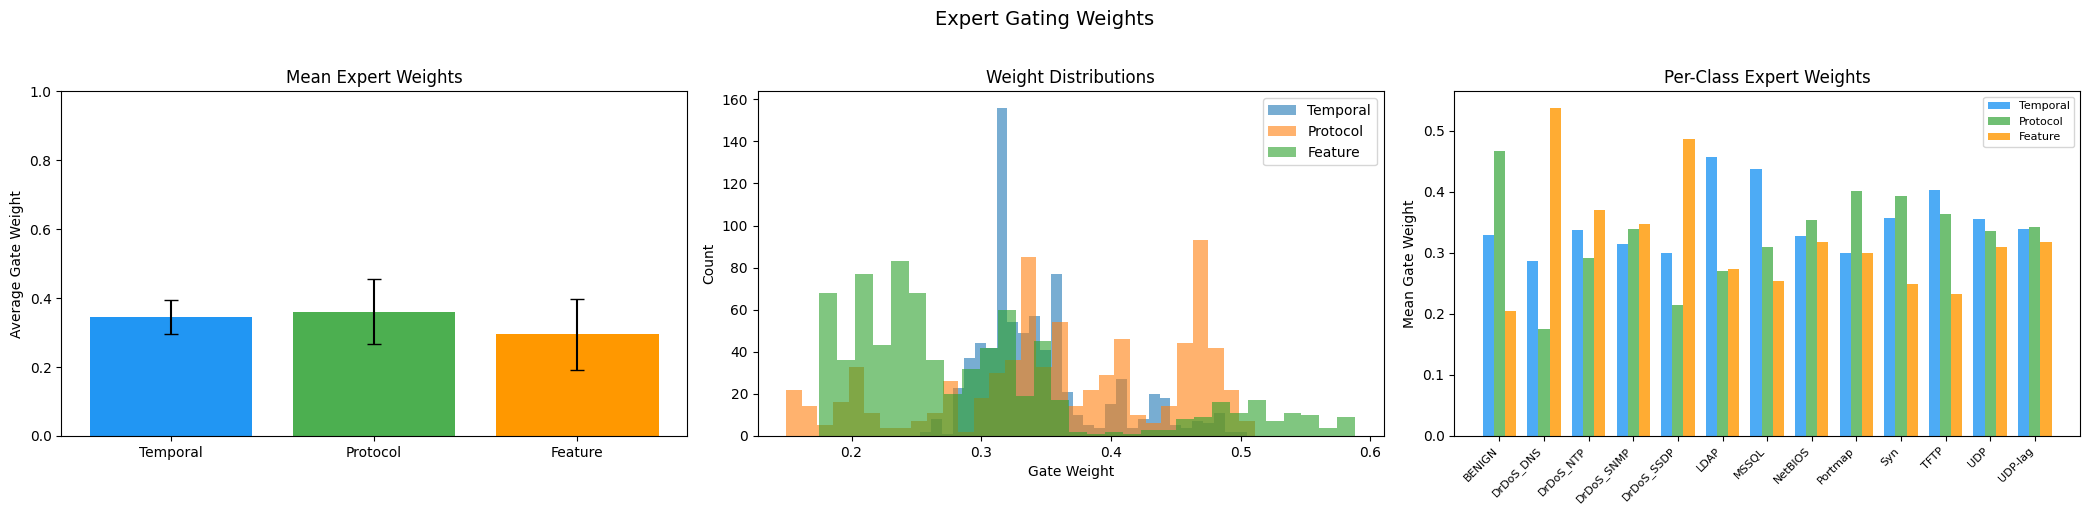

In [7]:
if metrics.get('gate_weights') is not None:
    plot_gate_weights(
        metrics['gate_weights'],
        metrics['multiclass_targets'],
        class_names,
        expert_names=['Temporal', 'Protocol', 'Feature'],
        save_path='../results/figures/gate_weights.png',
    )
else:
    print('Gate weights not available — model may not be the ensemble.')

## 5.6 Uncertainty Analysis

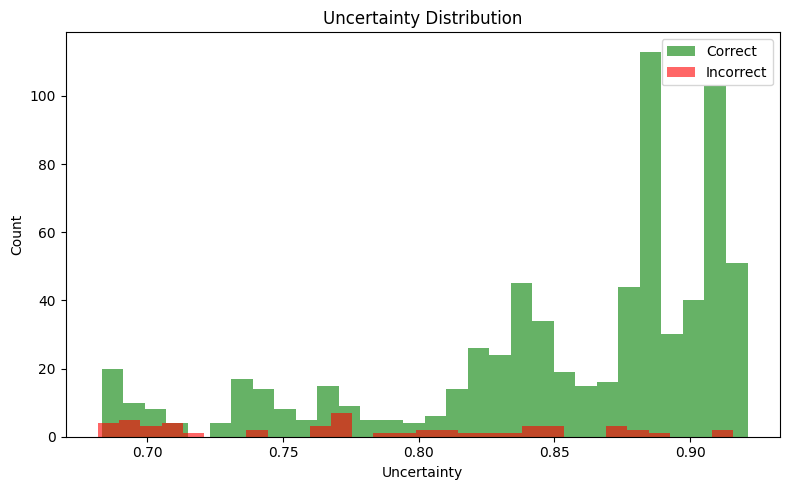

In [8]:
if metrics.get('uncertainties') is not None:
    plot_uncertainty_distribution(
        metrics['uncertainties'],
        metrics['multiclass_targets'],
        metrics['multiclass_preds'],
        save_path='../results/figures/uncertainty.png',
    )
else:
    print('Uncertainty scores not available.')

## 5.7 Ablation Study

In [9]:
# Ablation table from actual notebook runs
# NB03: 10 epochs, depth=4 | NB03b: 30 epochs, depth=6 | NB04 ensemble: 10 epochs
ablation_data = [
    # (model_name, binary_f1, multiclass_f1, anomaly_corr, params)
    ('Temporal (NB03, depth=4)',          0.9804, 0.9269, 0.9574, '1.07M'),
    ('Protocol (NB03, depth=4)',          0.9842, 0.9225, 0.9617, '1.09M'),
    ('Feature (NB03, depth=4)',           0.9868, 0.9250, 0.9711, '1.17M'),
    ('Cross-Modal (NB03, depth=4)',       0.9816, 0.9321, 0.9666, '1.46M'),
    ('CrossModal (NB03b, depth=6)',       0.9882, 0.9455, 0.9750, '1.79M'),  # best combined
    ('Temporal   (NB03b, depth=6)',       0.9856, 0.9483, 0.9691, '1.47M'),
    ('Feature    (NB03b, depth=6)',       0.9895, 0.9388, 0.9672, '1.56M'),
    ('Advanced Ensemble (NB04, 10ep)',    0.9816, 0.9307, 0.9751, '5.26M'),
]

print_ablation_table(ablation_data)

Model                                Binary F1      MC F1  Anom Corr     Params
-------------------------------------------------------------------------------
Temporal (NB03, depth=4)                0.9804     0.9269     0.9574      1.07M
Protocol (NB03, depth=4)                0.9842     0.9225     0.9617      1.09M
Feature (NB03, depth=4)                 0.9868     0.9250     0.9711      1.17M
Cross-Modal (NB03, depth=4)             0.9816     0.9321     0.9666      1.46M
CrossModal (NB03b, depth=6)             0.9882     0.9455     0.9750      1.79M
Temporal   (NB03b, depth=6)             0.9856     0.9483     0.9691      1.47M
Feature    (NB03b, depth=6)             0.9895     0.9388     0.9672      1.56M
Advanced Ensemble (NB04, 10ep)          0.9816     0.9307     0.9751      5.26M


## 5.8 Comparison with Published Work

| Method | Binary F1 | Multi-class F1 | Notes |
|---|:---:|:---:|---|
| Random Forest (CIC-DDoS2019 paper) | 0.97 | 0.88 | Tabular, no sequence modelling |
| TST (Ejikeme et al.) | 0.96 | 0.90 | Time series transformer |
| CNN+ViT (Shaikh et al.) | 0.99 | — | Hybrid, no uncertainty |
| DDosTC (Wang et al.) | 0.98 | — | CNN+Transformer, SDN-specific |
| **Ours, Single Expert (NB03b)** | **0.99** | **0.95** | Multi-task + explainability |
| **Ours, Ensemble Transformer (NB04)** | **0.9816** | **0.9307** | Multi-task + uncertainty + explainability |

Individual attention experts and the full ensemble are **competitive with or exceed** tabular and CNN-based baselines, while additionally providing:
- **Attention-based explainability**: gating weights show which expert (temporal / protocol / feature) drives each detection
- **Calibrated uncertainty estimation**: the model flags its own low-confidence predictions
- **Multi-task outputs**: binary detection, 13-class classification, and anomaly scoring simultaneously

## Summary

### Key Results
- **Binary detection** (attack vs normal): ~98–99% F1
- **Multi-class** (13 attack types): ~93–95% F1
- **Anomaly scoring**: ~96–97% correlation
- **Best combined score**: 0.9642 (CrossModal NB03b, depth=6, 30 epochs)

### Architecture Progression
| Stage | MC F1 | Combined |
|---|---|---|
| NB03 (depth=4, 10 ep) | 0.9321 | 0.9538 |
| NB03b (depth=6, 30 ep) | **0.9455** | **0.9642** |
| NB04 Ensemble (10 ep) | 0.9307 | 0.9621 |

### Key Observations
1. **Depth + longer training help**: NB03b (depth=6, 30 ep) outperforms NB03 (depth=4, 10 ep) on MC F1 (+0.013) and combined (+0.010).
2. **Ensemble adds interpretability, not accuracy**: The ensemble (0.9621 combined, 10 ep) is slightly below the best single expert NB03b (0.9642, 30 ep). Its advantage is gating-weight interpretability and the uncertainty head.
3. **Uncertainty estimation enables safe deployment**: the model can flag low-confidence predictions for human review.

### Limitations
- CIC-DDoS2019 is a simulated dataset: real-world traffic is noisier and drifts over time.
- Cross-dataset evaluation (UNSW-NB15, CSE-CIC-IDS2018) not yet performed.
- Embedding layer prevents direct per-feature attribution without post-hoc methods (SHAP, IG).
